<a href="https://colab.research.google.com/github/dorcasojo/Machine-learning-Assignment/blob/main/Exercise8_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

In [15]:
df = pd.read_csv('/content/EFIplus_medit.csv', sep=';')

In [16]:
print(df.columns)

Index(['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name',
       'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect',
       'Calib_hydrol',
       ...
       'Squalius malacitanus', 'Squalius pyrenaicus', 'Squalius torgalensis',
       'Thymallus thymallus', 'Tinca tinca', 'Zingel asper', 'Squalius sp',
       'Barbatula sp', 'Phoxinus sp', 'Iberochondrostoma_sp'],
      dtype='object', length=164)


In [17]:
df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [18]:
env_vars = [
    'Altitude',
    'Actual_river_slope',
    'Elevation_mean_catch',
    'prec_ann_catch',
    'temp_ann',
    'temp_jan',
    'temp_jul'
]

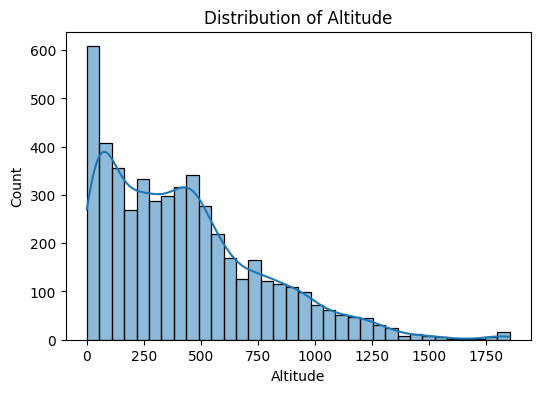

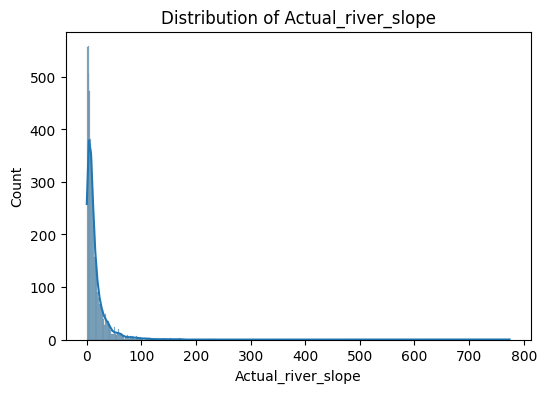

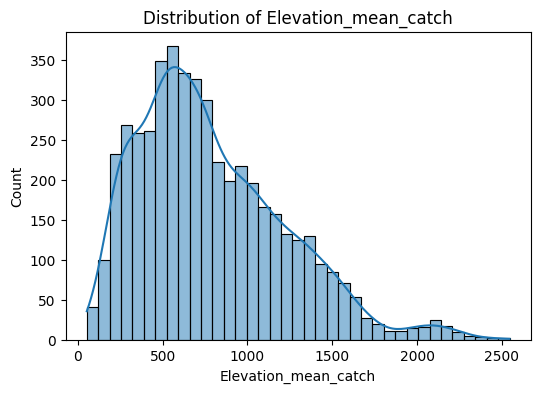

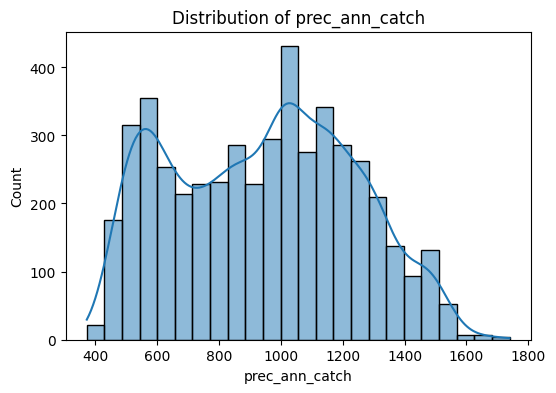

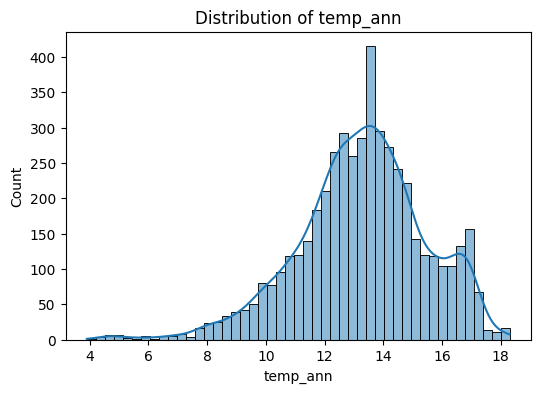

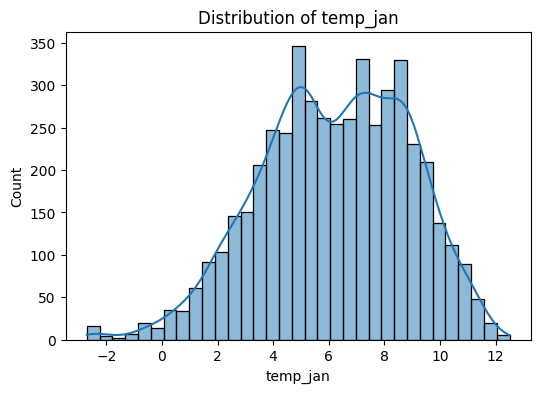

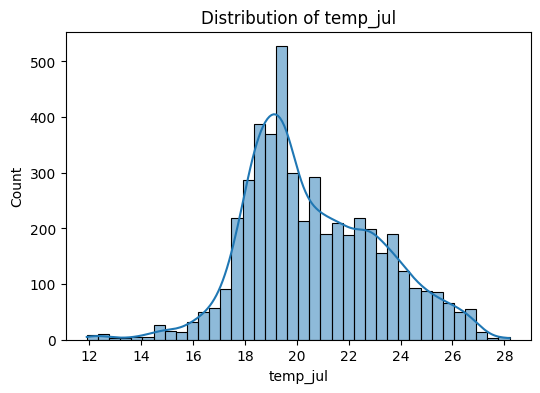

In [19]:
for var in env_vars:
    plt.figure(figsize=(6,4))
    sns.histplot(df[var], kde=True)
    plt.title(f'Distribution of {var}')
    plt.show()

In [21]:
df['log_Altitude'] = np.log1p(df['Altitude'])

df['log_Actual_river_slope'] = np.log1p(df['Actual_river_slope'])

df['log_prec_ann_catch'] = np.log1p(df['prec_ann_catch'])


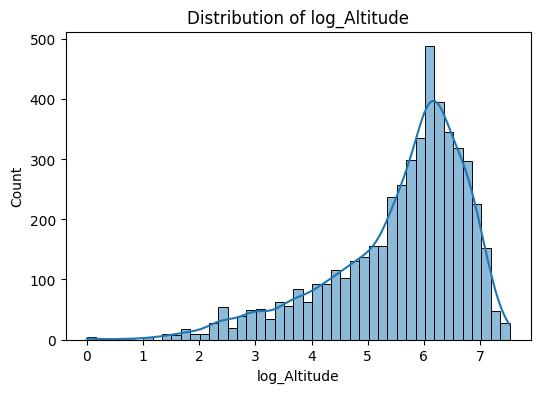

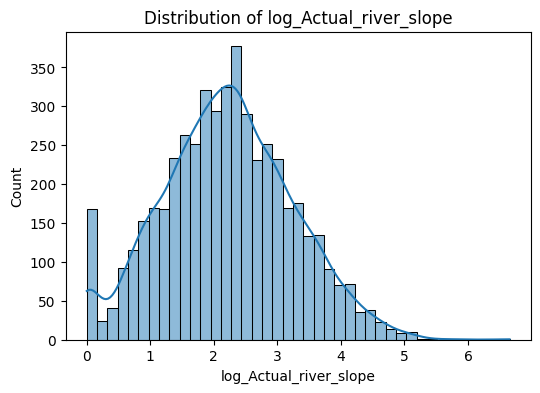

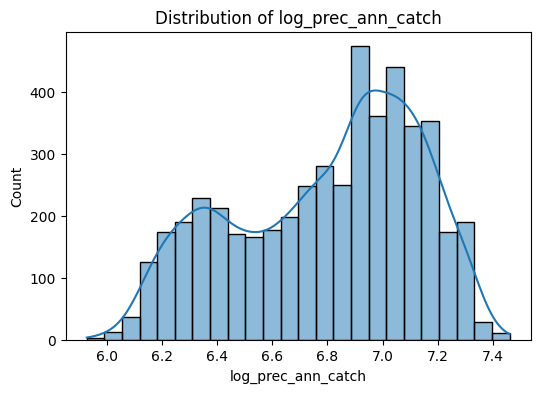

In [22]:
transformed_vars = [
    'log_Altitude',
    'log_Actual_river_slope',
    'log_prec_ann_catch'
]

for var in transformed_vars:
    plt.figure(figsize=(6,4))
    sns.histplot(df[var], kde=True)
    plt.title(f'Distribution of {var}')
    plt.show()

In [23]:
species_start = df.columns.get_loc('Abramis brama')

In [24]:
species_data = df.iloc[:, species_start:]

In [25]:
df['species_richness'] = species_data.sum(axis=1)

In [26]:
df[['species_richness']].head()

,species_richness
0,12.559034
1,17.265279
2,16.846760
3,17.638451
4,17.905735


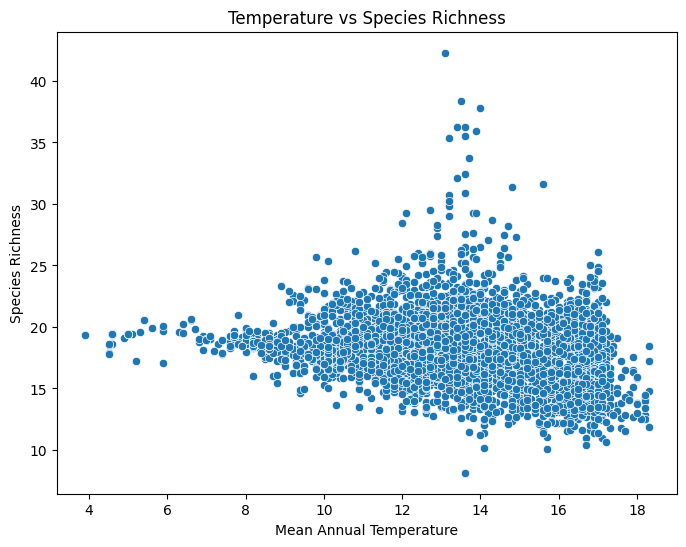

In [27]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['temp_ann'],
    y=df['species_richness']
)

plt.xlabel('Mean Annual Temperature')
plt.ylabel('Species Richness')
plt.title('Temperature vs Species Richness')

plt.show()

In [28]:
X = df[['temp_ann', 'species_richness']]
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

In [29]:
df['outlier'] = iso.fit_predict(X)

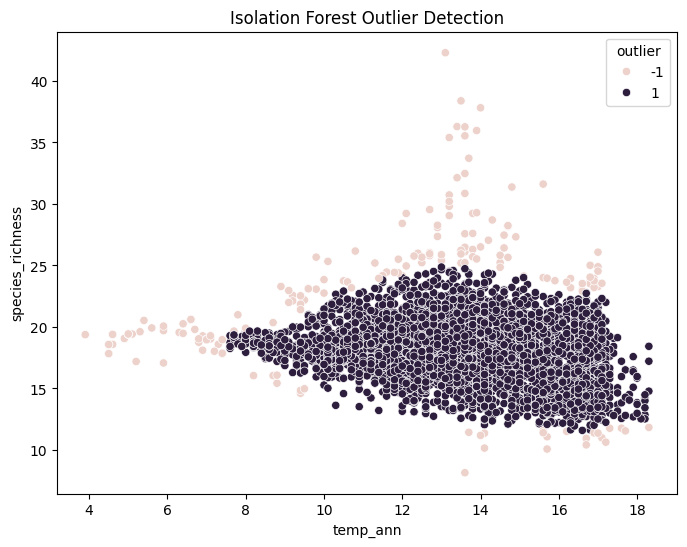

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='temp_ann',
    y='species_richness',
    hue='outlier',
    data=df
)

plt.title('Isolation Forest Outlier Detection')

plt.show()

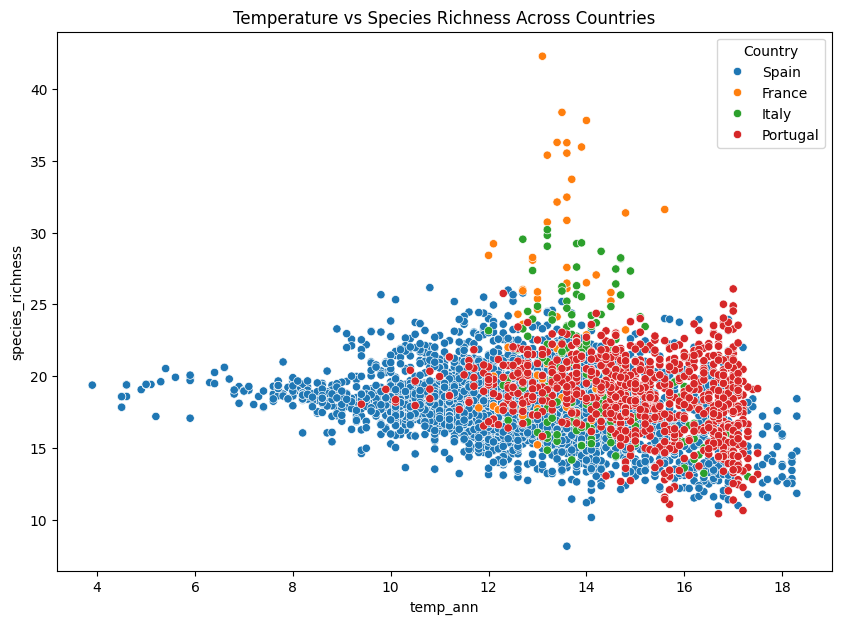

In [31]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='temp_ann',
    y='species_richness',
    hue='Country',
    data=df
)

plt.title('Temperature vs Species Richness Across Countries')

plt.show()